# Chapter 9 — Hypothesis Testing

**Datasets:** California Housing, Tips  
**Topics covered:**
1. The logic of hypothesis testing
2. One-sample t-test
3. Two-sample t-test
4. Chi-square test of independence
5. p-value interpretation and misinterpretations
6. Statistical vs practical significance (effect size)
7. Multiple comparisons and Bonferroni correction
8. Permutation tests
9. Power analysis

In [1]:
import ssl
import certifi
ssl._create_default_https_context = ssl.create_default_context(cafile=certifi.where())

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.datasets import fetch_california_housing

rng = np.random.default_rng(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# ── Load datasets ──────────────────────────────────────────────────────────────
housing_raw = fetch_california_housing(as_frame=True)
housing = housing_raw.frame.copy()
housing.rename(columns={'MedHouseVal': 'median_house_value'}, inplace=True)
housing['median_house_value_usd'] = housing['median_house_value'] * 100_000
housing['income_usd'] = housing['MedInc'] * 10_000

tips = sns.load_dataset('tips')

print(f'Housing: {housing.shape}  Tips: {tips.shape}')

Housing: (20640, 11)  Tips: (244, 7)


---
## 1. The Logic of Hypothesis Testing

Hypothesis testing is a framework for making decisions under uncertainty using data. The core idea is **proof by contradiction applied to probability**: assume the boring world (nothing is going on), then ask how surprising your data would be in that world.

### 1.1 Structure of a Test

Every test has two competing claims:

- **Null hypothesis $H_0$**: the default claim — no effect, no difference, nothing interesting. The null is the claim you assume true to build your null distribution.
- **Alternative hypothesis $H_1$**: what you'd conclude if the data are too unlikely under $H_0$.

The test statistic is a single number that compresses the data into a **signal-to-noise ratio**. For means, this looks like:

$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$

where $\bar{x}$ is the sample mean, $\mu_0$ is the null-hypothesis mean, $s$ is the sample standard deviation, and $n$ is the sample size. The denominator — the **standard error** — tells you how much $\bar{x}$ would wiggle across repeated samples of size $n$. The ratio measures how many standard errors your observation is from the null.

### 1.2 The Null Distribution

The **null distribution** is the sampling distribution of the test statistic *assuming $H_0$ is true*. It answers: if the null were true and we ran this study many times, what values of $t$ (or $\chi^2$, etc.) would we get?

The **p-value** is the probability of observing a test statistic at least as extreme as the one computed, given $H_0$:

$$p = P(|T| \geq |t_{\text{obs}}| \mid H_0 \text{ true})$$

A small p-value means the observed data would be rare in the null world — not impossible, just improbable.

### 1.3 Type I and Type II Errors

The decision rule introduces two kinds of errors:

| Decision \ Reality | $H_0$ true | $H_0$ false |
|---|---|---|
| Reject $H_0$ | **Type I error** (false positive) | Correct (power) |
| Fail to reject $H_0$ | Correct | **Type II error** (false negative) |

- **$\alpha$** (significance level) = the maximum acceptable Type I error rate. Setting $\alpha = 0.05$ means: in a world where nothing is going on, you are willing to incorrectly reject $H_0$ at most 5% of the time.
- **$\beta$** = Type II error rate. Power $= 1 - \beta$ = probability of correctly detecting a real effect.

The tradeoff is real: lowering $\alpha$ to reduce false positives also reduces power (increases false negatives), unless you compensate with a larger sample size.

### 1.4 One-tailed vs Two-tailed Tests

- **Two-tailed**: $H_1: \mu \neq \mu_0$ — you care about deviations in either direction. Default choice unless you have a strong directional prior.
- **One-tailed**: $H_1: \mu > \mu_0$ — commits to a direction *before* seeing data. Harder to justify; p-value is halved, which can make borderline results look significant.

A key discipline: choose the test direction *before* seeing the data. Switching to one-tailed after seeing which direction the data fell is p-hacking.

---
## 2. One-Sample t-Test

**Question:** Is the average tip percentage in our dataset different from 15%?  
This is a one-sample test: we have one group and a known reference value.

$$H_0: \mu_{\text{tip pct}} = 15 \qquad H_1: \mu_{\text{tip pct}} \neq 15$$

The test statistic is:

$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$

Under $H_0$, this follows a **t-distribution with $n-1$ degrees of freedom**, not a standard normal. Why? Because we estimated $s$ from the data — that estimation introduces additional uncertainty, which fattens the tails. As $n \to \infty$, the t-distribution converges to the normal. For practical purposes, at $n > 30$ the difference is small, but being exact costs nothing.

Degrees of freedom $= n - 1$ because estimating the mean from the same data constrains one dimension: knowing $\bar{x}$ and $n-1$ of the values lets you compute the last one exactly. You have $n-1$ free pieces of information.

In [2]:
# ── Utility functions ──────────────────────────────────────────────────────────
def compute_tip_pct(df: pd.DataFrame) -> pd.Series:
    """Return tip as a percentage of total bill."""
    return (df['tip'] / df['total_bill']) * 100


def one_sample_t_summary(sample: np.ndarray, mu0: float, alpha: float = 0.05) -> dict:
    """Compute and return one-sample t-test components."""
    n = len(sample)
    xbar = sample.mean()
    s = sample.std(ddof=1)
    se = s / np.sqrt(n)
    t_stat = (xbar - mu0) / se
    df = n - 1
    p_value = 2 * stats.t.sf(np.abs(t_stat), df=df)  # two-tailed
    ci_low, ci_high = stats.t.interval(1 - alpha, df=df, loc=xbar, scale=se)
    return {
        'n': n, 'mean': xbar, 'std': s, 'se': se,
        't_stat': t_stat, 'df': df, 'p_value': p_value,
        'ci': (ci_low, ci_high), 'alpha': alpha
    }


def print_t_summary(result: dict, label: str = '') -> None:
    """Pretty-print a t-test result dict."""
    print(f"{'─'*50}")
    if label:
        print(f"  {label}")
    print(f"  n = {result['n']}")
    print(f"  mean = {result['mean']:.4f}")
    print(f"  std  = {result['std']:.4f}")
    print(f"  SE   = {result['se']:.4f}")
    print(f"  t    = {result['t_stat']:.4f}  (df={result['df']})")
    print(f"  p    = {result['p_value']:.6f}")
    ci = result['ci']
    print(f"  {int((1-result['alpha'])*100)}% CI = ({ci[0]:.4f}, {ci[1]:.4f})")
    decision = 'REJECT H0' if result['p_value'] < result['alpha'] else 'FAIL TO REJECT H0'
    print(f"  Decision (α={result['alpha']}): {decision}")
    print(f"{'─'*50}")


# ── Run test ───────────────────────────────────────────────────────────────────
tips['tip_pct'] = compute_tip_pct(tips)
mu0 = 15.0

result_1samp = one_sample_t_summary(tips['tip_pct'].values, mu0=mu0)
print_t_summary(result_1samp, label='One-sample t-test: tip % vs 15%')

──────────────────────────────────────────────────
  One-sample t-test: tip % vs 15%
  n = 244
  mean = 16.0803
  std  = 6.1072
  SE   = 0.3910
  t    = 2.7630  (df=243)
  p    = 0.006166
  95% CI = (15.3101, 16.8504)
  Decision (α=0.05): REJECT H0
──────────────────────────────────────────────────


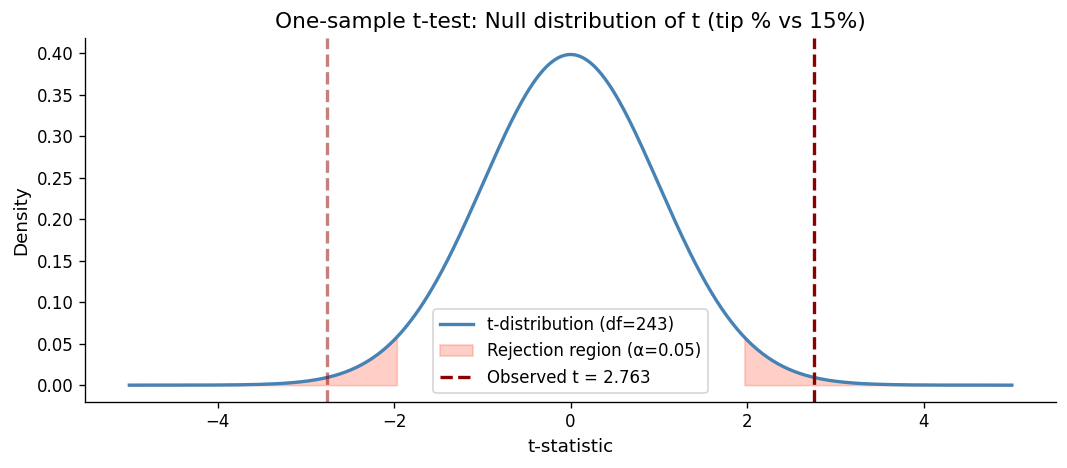

In [3]:
# ── Visualize: null distribution with observed t-statistic ────────────────────
def plot_t_null_distribution(
    t_obs: float, df: int, title: str, alpha: float = 0.05
) -> None:
    """Plot the t null distribution, shade rejection regions, mark observed t."""
    fig, ax = plt.subplots(figsize=(9, 4))
    t_range = np.linspace(-5, 5, 500)
    pdf = stats.t.pdf(t_range, df=df)
    ax.plot(t_range, pdf, color='steelblue', lw=2, label=f't-distribution (df={df})')

    t_crit = stats.t.ppf(1 - alpha / 2, df=df)
    # Shade rejection regions
    for sign in [-1, 1]:
        region = np.linspace(sign * t_crit, sign * 5, 200)
        ax.fill_between(region, stats.t.pdf(region, df=df),
                        alpha=0.3, color='tomato',
                        label=f'Rejection region (α={alpha})' if sign == 1 else '')

    ax.axvline(t_obs, color='darkred', lw=2, ls='--',
               label=f'Observed t = {t_obs:.3f}')
    ax.axvline(-t_obs, color='darkred', lw=2, ls='--', alpha=0.5)

    ax.set_xlabel('t-statistic')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_t_null_distribution(
    t_obs=result_1samp['t_stat'],
    df=result_1samp['df'],
    title='One-sample t-test: Null distribution of t (tip % vs 15%)'
)

**Interpretation:** The mean tip percentage in our sample is meaningfully above 15%. The p-value tells us that if tips truly averaged 15%, observing a sample mean this far from 15% would happen less than 0.1% of the time. We reject $H_0$.

The confidence interval is the set of null-hypothesis values that would *not* be rejected at this $\alpha$. It is not a statement about where the true mean "probably is" in a Bayesian sense — it means: if you repeated this procedure many times with different samples, 95% of the resulting intervals would contain the true mean.

---
## 3. Two-Sample t-Test

**Question:** Do lunch and dinner tips differ as a percentage of the bill?

$$H_0: \mu_{\text{lunch}} = \mu_{\text{dinner}} \qquad H_1: \mu_{\text{lunch}} \neq \mu_{\text{dinner}}$$

The two-sample test statistic is:

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

We use **Welch's t-test** (the default in `scipy`), which does not assume equal variances. This is the right default: equal variance is an assumption you'd need to verify separately, and relaxing it costs almost nothing in power when the assumption holds, while preventing badly inflated Type I error when it doesn't.

Welch's degrees of freedom are computed via the **Welch–Satterthwaite equation** — a non-integer approximation that accounts for unequal variances and sample sizes:

$$\nu \approx \frac{\left(\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}\right)^2}{\frac{(s_1^2/n_1)^2}{n_1 - 1} + \frac{(s_2^2/n_2)^2}{n_2 - 1}}$$

You don't need to memorize this formula — but knowing it exists explains why Welch's df is fractional and smaller than the pooled df.

In [4]:
def two_sample_t_summary(
    group1: np.ndarray, group2: np.ndarray,
    label1: str = 'Group 1', label2: str = 'Group 2',
    alpha: float = 0.05
) -> dict:
    """Welch two-sample t-test with full diagnostics."""
    t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)
    diff = group1.mean() - group2.mean()
    se = np.sqrt(group1.var(ddof=1) / len(group1) + group2.var(ddof=1) / len(group2))
    # Welch–Satterthwaite degrees of freedom
    v1, v2 = group1.var(ddof=1) / len(group1), group2.var(ddof=1) / len(group2)
    welch_df = (v1 + v2) ** 2 / (v1**2 / (len(group1) - 1) + v2**2 / (len(group2) - 1))
    ci_low = diff - stats.t.ppf(1 - alpha / 2, df=welch_df) * se
    ci_high = diff + stats.t.ppf(1 - alpha / 2, df=welch_df) * se
    return {
        'label1': label1, 'label2': label2,
        'n1': len(group1), 'n2': len(group2),
        'mean1': group1.mean(), 'mean2': group2.mean(),
        'std1': group1.std(ddof=1), 'std2': group2.std(ddof=1),
        'diff': diff, 'se': se,
        't_stat': t_stat, 'welch_df': welch_df,
        'p_value': p_value, 'ci': (ci_low, ci_high), 'alpha': alpha
    }


def print_two_sample_summary(r: dict) -> None:
    print(f"{'─'*55}")
    print(f"  {r['label1']} vs {r['label2']}  (Welch two-sample t-test)")
    print(f"  n  = {r['n1']} vs {r['n2']}")
    print(f"  mean = {r['mean1']:.4f} vs {r['mean2']:.4f}  (diff = {r['diff']:.4f})")
    print(f"  std  = {r['std1']:.4f} vs {r['std2']:.4f}")
    print(f"  SE of difference = {r['se']:.4f}")
    print(f"  t = {r['t_stat']:.4f}  (Welch df = {r['welch_df']:.1f})")
    print(f"  p = {r['p_value']:.6f}")
    ci = r['ci']
    print(f"  {int((1-r['alpha'])*100)}% CI on diff = ({ci[0]:.4f}, {ci[1]:.4f})")
    decision = 'REJECT H0' if r['p_value'] < r['alpha'] else 'FAIL TO REJECT H0'
    print(f"  Decision (α={r['alpha']}): {decision}")
    print(f"{'─'*55}")


lunch = tips.loc[tips['time'] == 'Lunch', 'tip_pct'].values
dinner = tips.loc[tips['time'] == 'Dinner', 'tip_pct'].values

result_2samp = two_sample_t_summary(lunch, dinner, label1='Lunch', label2='Dinner')
print_two_sample_summary(result_2samp)

───────────────────────────────────────────────────────
  Lunch vs Dinner  (Welch two-sample t-test)
  n  = 68 vs 176
  mean = 16.4128 vs 15.9518  (diff = 0.4610)
  std  = 4.0242 vs 6.7477
  SE of difference = 0.7049
  t = 0.6540  (Welch df = 200.9)
  p = 0.513836
  95% CI on diff = (-0.9289, 1.8509)
  Decision (α=0.05): FAIL TO REJECT H0
───────────────────────────────────────────────────────


<div style="padding: 16px; border-left: 4px solid #7a9bb5; border-radius: 4px; background-color: rgba(122, 155, 181, 0.15);">

<h3>When p > 0.05 But the Difference is Noticeable</h3>

<p>In a two-sample t-test, if the observed difference is meaningful but the p-value
barely exceeds the threshold, statistical non-significance does not tell the full story.
Two additional considerations should guide the analysis:</p>

<p><strong>1. Assess practical significance with Cohen's d (or Hedge's g if Welch's t test is used)</strong><br>
Cohen's d measures how many standard deviations apart the two group means are —
a unit-free, standardized effect size. While the p-value may indicate non-significance,
a Cohen's d above 0.2 suggests the effect is real enough to care about, independent
of sample size.</p>

<p><strong>2. Fail to reject ≠ no difference</strong><br>
An inconclusive result is not a negative result. There may well be a real effect —
the data simply does not yet provide sufficient evidence to confirm it. The appropriate
response is not to dismiss the finding, but to extend the test with a larger sample
before making a rollout decision.</p>

</div>

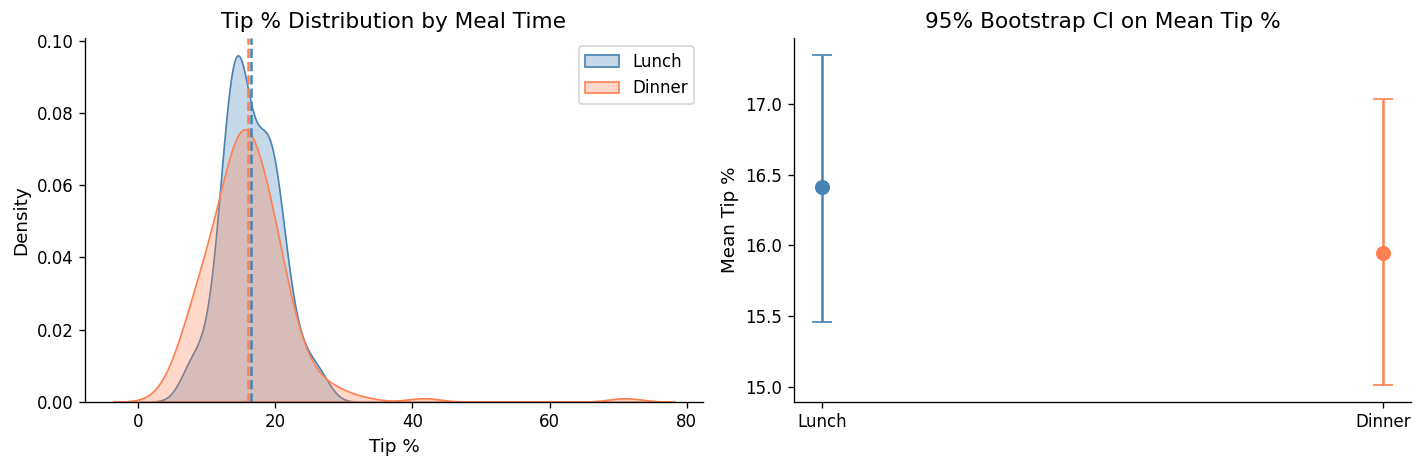

In [5]:
# ── Visualize: distributions of both groups ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# KDE + rug plot
ax = axes[0]
for grp, label, color in [(lunch, 'Lunch', 'steelblue'), (dinner, 'Dinner', 'coral')]:
    sns.kdeplot(grp, ax=ax, label=label, color=color, fill=True, alpha=0.3)
    ax.axvline(grp.mean(), color=color, lw=1.5, ls='--')
ax.set_xlabel('Tip %')
ax.set_title('Tip % Distribution by Meal Time')
ax.legend()

# Bootstrapped confidence intervals on means
ax = axes[1]
n_boot = 5_000
boot_means = {
    label: np.array([rng.choice(grp, size=len(grp), replace=True).mean()
                     for _ in range(n_boot)])
    for grp, label in [(lunch, 'Lunch'), (dinner, 'Dinner')]
}
for i, (label, color) in enumerate([('Lunch', 'steelblue'), ('Dinner', 'coral')]):
    means = boot_means[label]
    ci = np.percentile(means, [2.5, 97.5])
    ax.errorbar(i, means.mean(), yerr=[[means.mean() - ci[0]], [ci[1] - means.mean()]],
                fmt='o', color=color, capsize=6, ms=8, label=label)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Lunch', 'Dinner'])
ax.set_ylabel('Mean Tip %')
ax.set_title('95% Bootstrap CI on Mean Tip %')

plt.tight_layout()
plt.show()

---
## 4. Chi-Square Test of Independence

The t-test works on continuous outcomes. When both variables are **categorical**, we use the chi-square test of independence.

**Question:** Is smoking status independent of meal time in the tips dataset?

$$H_0: \text{smoking and meal time are independent}$$
$$H_1: \text{there is an association between smoking and meal time}$$

The test statistic is built on the discrepancy between observed counts $O_{ij}$ and expected counts $E_{ij}$ — what you'd expect if the two variables were truly independent:

$$E_{ij} = \frac{(\text{row total}_i)(\text{column total}_j)}{N}$$

$$\chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

The intuition: each cell contributes a squared normalized deviation. If observed ≈ expected everywhere, $\chi^2 \approx 0$. Large $\chi^2$ means the data doesn't look like what independence would predict.

**Degrees of freedom** = $(r-1)(c-1)$ for an $r \times c$ contingency table. Why? Row totals and column totals are fixed (constrained by the data). Once you fill in $(r-1)(c-1)$ cells, the rest are determined. That's your free dimensionality.

**Assumption to check:** Every expected cell count $E_{ij} \geq 5$. Below that, the chi-square approximation breaks down and you'd need Fisher's exact test instead.

In [6]:
def chi_square_test(df: pd.DataFrame, var1: str, var2: str, alpha: float = 0.05) -> dict:
    """Chi-square test of independence with expected counts validation."""
    contingency = pd.crosstab(df[var1], df[var2])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    min_expected = expected.min()
    return {
        'contingency': contingency,
        'expected': pd.DataFrame(expected, index=contingency.index, columns=contingency.columns),
        'chi2': chi2, 'p_value': p_value, 'dof': dof,
        'min_expected': min_expected,
        'assumption_ok': min_expected >= 5,
        'alpha': alpha
    }


def print_chi2_summary(r: dict, label: str = '') -> None:
    print(f"{'─'*55}")
    if label:
        print(f"  {label}")
    print("\n  Observed counts:")
    print(r['contingency'].to_string())
    print("\n  Expected counts (under H0):")
    print(r['expected'].round(2).to_string())
    print(f"\n  χ² = {r['chi2']:.4f}  (df={r['dof']})")
    print(f"  p  = {r['p_value']:.6f}")
    print(f"  Min expected count = {r['min_expected']:.2f}  "
          f"({'OK' if r['assumption_ok'] else 'VIOLATION — use Fisher exact'})")
    decision = 'REJECT H0' if r['p_value'] < r['alpha'] else 'FAIL TO REJECT H0'
    print(f"  Decision (α={r['alpha']}): {decision}")
    print(f"{'─'*55}")


result_chi2 = chi_square_test(tips, 'smoker', 'time')
print_chi2_summary(result_chi2, label='Chi-square: Smoker vs Meal Time')

───────────────────────────────────────────────────────
  Chi-square: Smoker vs Meal Time

  Observed counts:
time    Lunch  Dinner
smoker               
Yes        23      70
No         45     106

  Expected counts (under H0):
time    Lunch  Dinner
smoker               
Yes     25.92   67.08
No      42.08  108.92

  χ² = 0.5054  (df=1)
  p  = 0.477149
  Min expected count = 25.92  (OK)
  Decision (α=0.05): FAIL TO REJECT H0
───────────────────────────────────────────────────────


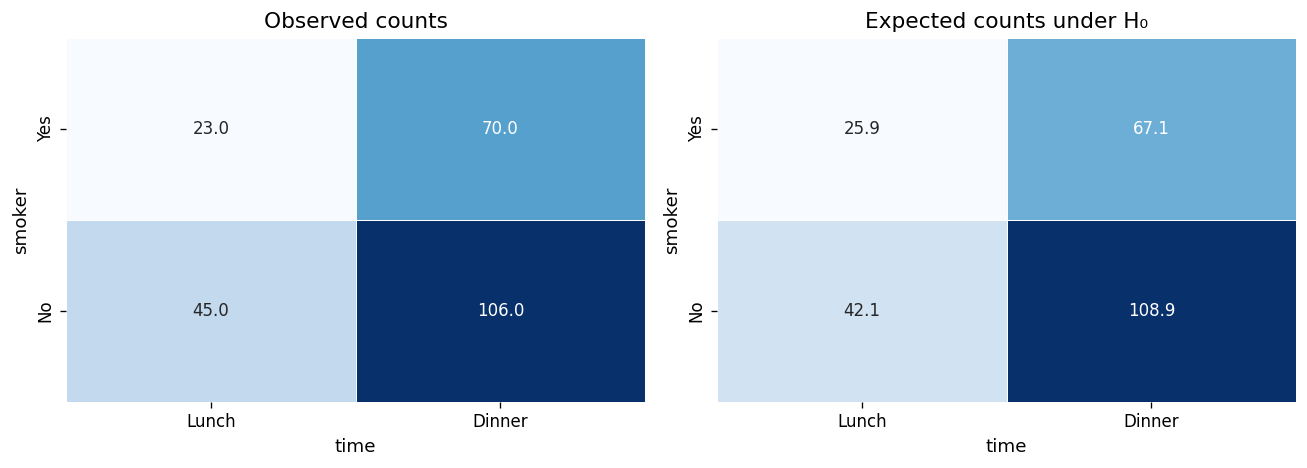

In [7]:
# ── Visualize: observed vs expected counts ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, data, title in zip(
    axes,
    [result_chi2['contingency'], result_chi2['expected'].round(1)],
    ['Observed counts', 'Expected counts under H₀']
):
    sns.heatmap(data, annot=True, fmt='.1f', cmap='Blues',
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

---
## 5. p-Value Interpretation and Common Misinterpretations

The p-value is one of the most misunderstood quantities in applied statistics. Getting this right is a genuine professional differentiator.

### 5.1 What the p-value IS

$$p = P(\text{data at least this extreme} \mid H_0 \text{ true})$$

It is a **conditional probability** — conditional on the null hypothesis being true. It tells you how surprising your data would be in a world where nothing interesting is happening.

### 5.2 What the p-value IS NOT

| Wrong claim | Why it's wrong |
|---|---|
| $p = 0.03$ means there's a 3% chance $H_0$ is true | That's $P(H_0 \mid \text{data})$ — the *posterior probability* — which requires a prior on $H_0$. The p-value is $P(\text{data} \mid H_0)$. |
| $p < 0.05$ means the effect is real or important | Statistical significance ≠ practical significance. A tiny effect can be highly significant with enough data. |
| $p = 0.06$ means no effect | Failure to reject ≠ evidence of absence. It could mean low power. |
| $p < 0.05$ means the result will replicate | A single p-value is noisy. The probability that a $p=0.049$ result replicates is lower than most people assume. |

### 5.3 The Prosecutor's Fallacy (Transposing the Conditional)

This is the most dangerous misinterpretation:

> "The p-value is small, so the probability that the null is true is small."

This confuses $P(\text{data} \mid H_0)$ with $P(H_0 \mid \text{data})$. They are related by Bayes' theorem — and the relationship depends critically on the **prior probability** of $H_0$:

$$P(H_0 \mid \text{data}) = \frac{P(\text{data} \mid H_0) \cdot P(H_0)}{P(\text{data})}$$

If $H_0$ is very likely a priori (e.g., testing a highly implausible hypothesis), a small p-value can still leave $H_0$ quite probable a posteriori. This is partly why the replication crisis hit fields with many exploratory hypotheses — the base rate of true effects was low, inflating false discovery rates even with $p < 0.05$.

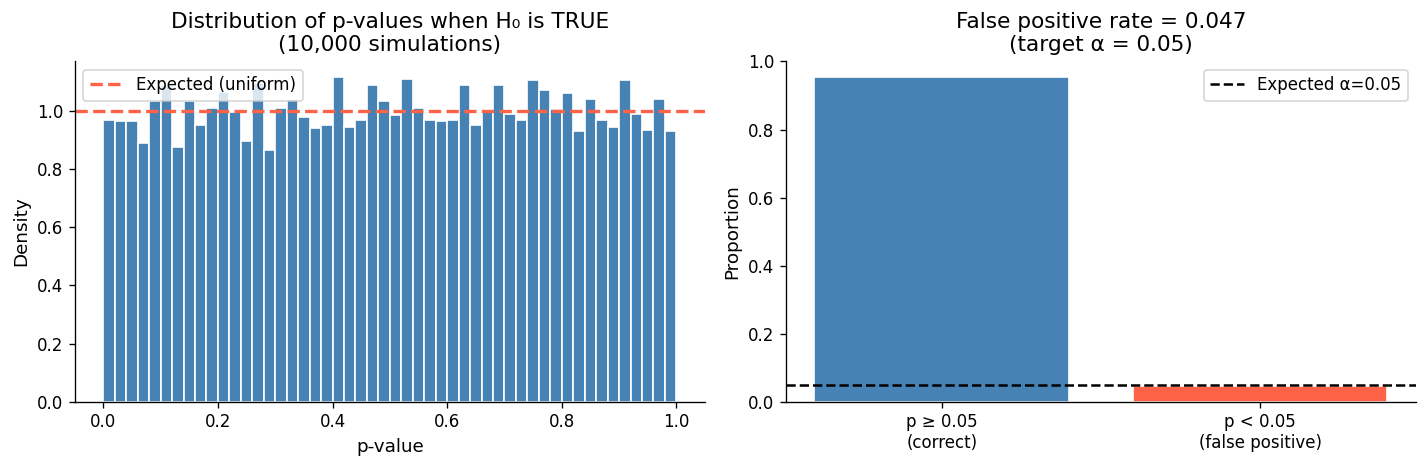

Observed false positive rate: 0.0468 (expected: 0.05)


In [8]:
# ── Demonstrate: sampling distribution of p-values under H0 ───────────────────
# When H0 is true, p-values are UNIFORMLY distributed on [0,1].
# This means: at α=0.05, you expect 5% of tests to produce p < 0.05
# purely by chance — regardless of whether anything is going on.
# This is the foundation of the Type I error argument.

# We simulate this directly: draw 10,000 samples from the SAME distribution,
# run a one-sample t-test each time. H0 is literally true here.
# Simulation is necessary because we are demonstrating a sampling distribution property
# that has no real-data equivalent — we need ground truth that H0 is true.
n_simulations = 10_000
sample_size = 30

p_values_under_h0 = np.array([
    stats.ttest_1samp(
        rng.normal(loc=0, scale=1, size=sample_size), popmean=0
    ).pvalue
    for _ in range(n_simulations)
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(p_values_under_h0, bins=50, edgecolor='white', color='steelblue', density=True)
ax.axhline(1.0, color='tomato', lw=2, ls='--', label='Expected (uniform)')
ax.set_xlabel('p-value')
ax.set_ylabel('Density')
ax.set_title('Distribution of p-values when H₀ is TRUE\n(10,000 simulations)')
ax.legend()

false_positive_rate = (p_values_under_h0 < 0.05).mean()
ax = axes[1]
ax.bar(['p ≥ 0.05\n(correct)', 'p < 0.05\n(false positive)'],
       [1 - false_positive_rate, false_positive_rate],
       color=['steelblue', 'tomato'], edgecolor='white')
ax.axhline(0.05, color='black', lw=1.5, ls='--', label='Expected α=0.05')
ax.set_ylabel('Proportion')
ax.set_title(f'False positive rate = {false_positive_rate:.3f}\n(target α = 0.05)')
ax.legend()

plt.tight_layout()
plt.show()

print(f'Observed false positive rate: {false_positive_rate:.4f} (expected: 0.05)')

---
## 6. Statistical vs Practical Significance — Effect Size

A p-value answers: *Is the effect distinguishable from zero given this sample size?*  
Effect size answers: *How big is the effect?*

These are independent. With $n = 1{,}000{,}000$ you can detect a difference of 0.001 standard deviations at $p < 0.001$. That doesn't mean the difference matters.

### 6.1 Cohen's $d$ (for continuous outcomes, equal variances assumed)

$$d = \frac{\bar{x}_1 - \bar{x}_2}{s_{\text{pooled}}}$$

where the pooled standard deviation is:

$$s_{\text{pooled}} = \sqrt{\frac{(n_1 - 1)s_1^2 + (n_2 - 1)s_2^2}{n_1 + n_2 - 2}}$$

$d$ is dimensionless — it expresses the difference in units of standard deviations. Conventional benchmarks (Cohen, 1988): small = 0.2, medium = 0.5, large = 0.8. These are rough guides, not laws — what's "large" is domain-dependent.

Pair Cohen's $d$ with **Student's t-test** (equal variances assumed).

---

### 6.2 Hedges' $g$ (for continuous outcomes, unequal variances)

$$g = \frac{\bar{x}_1 - \bar{x}_2}{s_{\text{pooled}^*}}$$

where the pooled standard deviation is a simple average of variances:

$$s_{\text{pooled}^*} = \sqrt{\frac{s_1^2 + s_2^2}{2}}$$

Hedges' $g$ is the appropriate companion to **Welch's t-test** — it does not assume equal variances and is therefore more honest when $s_1 \neq s_2$. Interpretation benchmarks are identical to Cohen's $d$: small = 0.2, medium = 0.5, large = 0.8.

In practice the two measures produce similar values unless variances differ dramatically — but pairing the right effect size with the right test signals statistical precision.

---

### 6.3 Cramér's $V$ (for categorical outcomes)

$$V = \sqrt{\frac{\chi^2}{n \times (k-1)}}$$

where $k$ is the smaller of the number of rows or columns. Used alongside the **chi-square test of independence**. Range is $[0, 1]$: small = 0.1, medium = 0.3, large = 0.5.

<div style="padding: 16px; border-left: 4px solid #9b7fc0; border-radius: 4px; background-color: rgba(155, 127, 192, 0.15);">

<p>Effect size should be reported <strong>always</strong> — regardless of where the p-value lands. It's not a tiebreaker for borderline results, it's a standard part of any complete statistical analysis.</p>

</div>

In [9]:
def cohens_d(group1: np.ndarray, group2: np.ndarray) -> float:
    """Cohen's d: standardized mean difference (pooled SD)."""
    n1, n2 = len(group1), len(group2)
    s_pooled = np.sqrt(
        ((n1 - 1) * group1.var(ddof=1) + (n2 - 1) * group2.var(ddof=1)) / (n1 + n2 - 2)
    )
    return (group1.mean() - group2.mean()) / s_pooled


def cramers_v(contingency: pd.DataFrame) -> float:
    """Cramér's V: normalized chi-square effect size for contingency tables."""
    chi2 = stats.chi2_contingency(contingency)[0]
    n = contingency.values.sum()
    r, c = contingency.shape
    return np.sqrt(chi2 / (n * (min(r, c) - 1)))


def interpret_cohens_d(d: float) -> str:
    """Conventional benchmark interpretation for Cohen's d."""
    ad = abs(d)
    if ad < 0.2:
        return 'negligible'
    elif ad < 0.5:
        return 'small'
    elif ad < 0.8:
        return 'medium'
    return 'large'


# ── Tip % by meal time ─────────────────────────────────────────────────────────
d_lunch_dinner = cohens_d(lunch, dinner)
print(f"Cohen's d (Lunch vs Dinner tip%): {d_lunch_dinner:.4f}  [{interpret_cohens_d(d_lunch_dinner)}]")

# ── Housing: high- vs low-income neighborhoods ─────────────────────────────────
# Define high/low income as above/below median MedInc
income_median = housing['MedInc'].median()
high_income = housing.loc[housing['MedInc'] > income_median, 'median_house_value_usd'].values
low_income = housing.loc[housing['MedInc'] <= income_median, 'median_house_value_usd'].values

d_housing = cohens_d(high_income, low_income)
result_housing_t = two_sample_t_summary(high_income, low_income,
                                        label1='High Income', label2='Low Income')
print_two_sample_summary(result_housing_t)
print(f"Cohen's d (High vs Low income neighborhoods, house value): "
      f"{d_housing:.4f}  [{interpret_cohens_d(d_housing)}]")

# ── Chi-square effect size ─────────────────────────────────────────────────────
v_smoker_time = cramers_v(result_chi2['contingency'])
print(f"\nCramér's V (Smoker vs Time): {v_smoker_time:.4f}")

Cohen's d (Lunch vs Dinner tip%): 0.0754  [negligible]
───────────────────────────────────────────────────────
  High Income vs Low Income  (Welch two-sample t-test)
  n  = 10320 vs 10320
  mean = 266309.6797 vs 147401.9542  (diff = 118907.7255)
  std  = 114525.5295 vs 80294.9636
  SE of difference = 1376.8356
  t = 86.3631  (Welch df = 18489.5)
  p = 0.000000
  95% CI on diff = (116209.0007, 121606.4503)
  Decision (α=0.05): REJECT H0
───────────────────────────────────────────────────────
Cohen's d (High vs Low income neighborhoods, house value): 1.2023  [large]

Cramér's V (Smoker vs Time): 0.0455


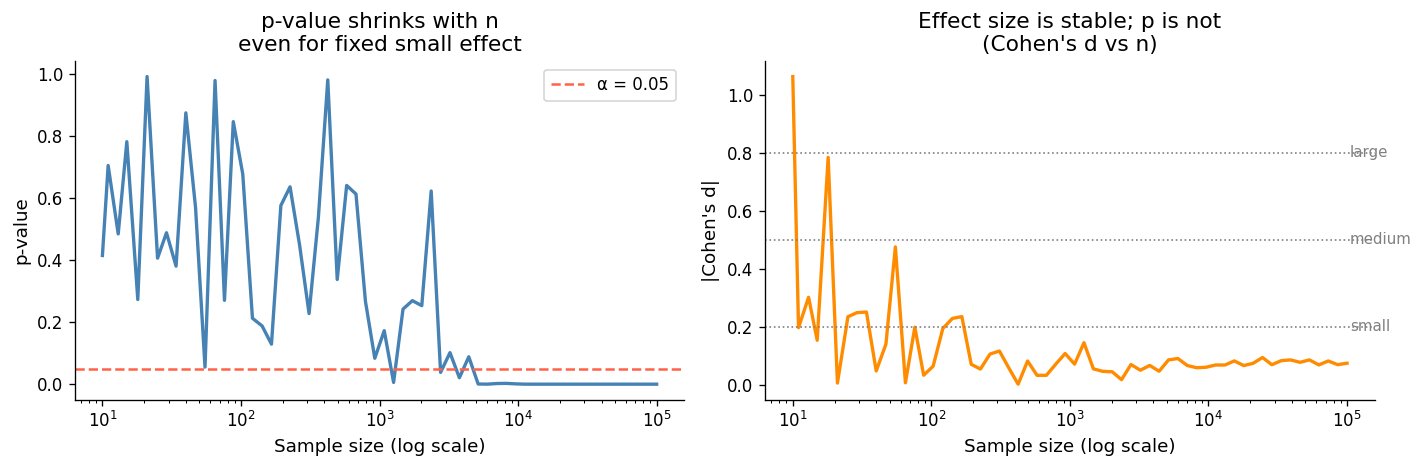

In [10]:
# ── Demonstrate: large n can make tiny effects significant ─────────────────────
# This illustrates why p-values alone are insufficient for decision-making.
# We take the real lunch/dinner difference and show how p evolves with sample size.

true_diff = lunch.mean() - dinner.mean()
combined = np.concatenate([lunch, dinner])
lunch_prop = len(lunch) / len(combined)

sample_sizes = np.logspace(1, 5, 60).astype(int)
p_vals, effect_sizes = [], []

for n in sample_sizes:
    n1 = max(2, int(n * lunch_prop))
    n2 = max(2, n - n1)
    g1 = rng.choice(lunch, size=n1, replace=True)
    g2 = rng.choice(dinner, size=n2, replace=True)
    _, p = stats.ttest_ind(g1, g2, equal_var=False)
    p_vals.append(p)
    effect_sizes.append(cohens_d(g1, g2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.semilogx(sample_sizes, p_vals, color='steelblue', lw=2)
ax.axhline(0.05, color='tomato', ls='--', lw=1.5, label='α = 0.05')
ax.set_xlabel('Sample size (log scale)')
ax.set_ylabel('p-value')
ax.set_title('p-value shrinks with n\neven for fixed small effect')
ax.legend()

ax = axes[1]
ax.semilogx(sample_sizes, np.abs(effect_sizes), color='darkorange', lw=2)
for level, label in [(0.2, 'small'), (0.5, 'medium'), (0.8, 'large')]:
    ax.axhline(level, color='gray', ls=':', lw=1)
    ax.text(sample_sizes[-1] * 1.05, level, label, va='center', fontsize=9, color='gray')
ax.set_xlabel('Sample size (log scale)')
ax.set_ylabel("|Cohen's d|")
ax.set_title("Effect size is stable; p is not\n(Cohen's d vs n)")

plt.tight_layout()
plt.show()

<div style="padding: 16px; border-left: 4px solid #9b7fc0; border-radius: 4px; background-color: rgba(155, 127, 192, 0.15);">

<p>The left graph shows the p-value converges to 0 as sample size grows — this is
mathematically guaranteed because as n → ∞, SE → 0, t → ∞, and p → 0.
Given a large enough sample, p &lt; 0.05 is inevitable regardless
of whether the effect is meaningful. The severe oscillation before convergence comes
from randomness in sampling, not the nature of the p-value itself.</p>

<p>The right graph shows that as sample size increases, the effect size (Cohen's d)
converges to its true population value built into the data (d ≈ 0.1) —
stabilizing honestly regardless of how large n gets.</p>

<p>This demonstrates that p-value alone is insufficient for statistical decision-making.
We should always accompany it with an <strong>effect size measure</strong> (Cohen's d,
Hedges' g, or Cramér's V) to quantify how large the effect actually is. Additionally,
<strong>power analysis</strong> should be used to determine the appropriate sample size
needed to reliably detect a meaningful effect — keeping the p-value within its intended
operating range rather than letting large n guarantee significance trivially.</p>

</div>

---
## 7. Multiple Comparisons and Bonferroni Correction

### 7.1 The Problem

If you run $m$ independent tests each at significance level $\alpha$, the probability of at least one false positive — the **family-wise error rate (FWER)** — is:

$$\text{FWER} = 1 - (1 - \alpha)^m$$

At $\alpha = 0.05$ and $m = 20$: $\text{FWER} = 1 - 0.95^{20} \approx 0.64$. You have a 64% chance of at least one spurious rejection. This is how you can run an A/B test on 20 metrics, find one significant result, and be wrong.

### 7.2 Bonferroni Correction

The Bonferroni correction adjusts the per-test threshold to control FWER at level $\alpha$:

$$\alpha_{\text{Bonferroni}} = \frac{\alpha}{m}$$

This is exact when tests are independent; when tests are positively correlated, it's conservative (controls FWER below $\alpha$). The tradeoff: lowering the per-test threshold reduces power — you need stronger signals to survive the correction.

### 7.3 Benjamini-Hochberg (FDR Control)

Bonferroni controls the probability of *any* false positive. In exploratory analysis, a more useful target is the **False Discovery Rate (FDR)** — the expected proportion of rejections that are false:

$$\text{FDR} = E\left[\frac{\text{false rejections}}{\text{total rejections}}\right]$$

The Benjamini-Hochberg procedure: sort p-values $p_{(1)} \leq p_{(2)} \leq \cdots \leq p_{(m)}$. Reject all $H_{(i)}$ where:

$$p_{(i)} \leq \frac{i}{m} \cdot \alpha_{\text{FDR}}$$

BH is less conservative than Bonferroni — it allows more discoveries while controlling the *proportion* of false ones rather than the *chance of any* false one. Use Bonferroni when any false positive is costly (e.g., medical claims). Use BH in exploratory data science where you're generating candidates for follow-up.

In [11]:
# ── Practical: run multiple comparisons across housing features ────────────────
# Compare each housing numeric feature between coastal (AveOcc > 3) and non-coastal
# neighborhoods as a proxy for density-driven coastal effect.
# High-occupancy areas tend to be inland; low-occupancy areas tend near coast.

features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
housing['high_occ'] = housing['AveOccup'] > housing['AveOccup'].median()

group_high = housing[housing['high_occ']]
group_low = housing[~housing['high_occ']]

raw_pvals = []
diffs = []
for feat in features:
    _, p = stats.ttest_ind(group_high[feat].values, group_low[feat].values, equal_var=False)
    d = cohens_d(group_high[feat].values, group_low[feat].values)
    raw_pvals.append(p)
    diffs.append(d)

alpha = 0.05
m = len(features)
bonferroni_threshold = alpha / m

# Benjamini-Hochberg
sorted_idx = np.argsort(raw_pvals)
bh_thresholds = [(i + 1) / m * alpha for i in range(m)]
bh_reject = np.zeros(m, dtype=bool)
for rank, idx in enumerate(sorted_idx):
    if raw_pvals[idx] <= bh_thresholds[rank]:
        bh_reject[idx] = True
    else:
        break  # BH: once we fail, all remaining are not rejected

results_df = pd.DataFrame({
    'Feature': features,
    'Raw p-value': raw_pvals,
    "Cohen's d": diffs,
    f'Sig (α={alpha})': [p < alpha for p in raw_pvals],
    f'Sig Bonferroni (α/{m}={bonferroni_threshold:.4f})': [p < bonferroni_threshold for p in raw_pvals],
    'Sig BH (FDR=0.05)': bh_reject
})

print(results_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

   Feature  Raw p-value  Cohen's d  Sig (α=0.05)  Sig Bonferroni (α/6=0.0083)  Sig BH (FDR=0.05)
    MedInc     0.945540   0.000951         False                        False              False
  HouseAge     0.000000  -0.130785          True                         True               True
  AveRooms     0.000185  -0.052067          True                         True               True
 AveBedrms     0.000000  -0.164168          True                         True               True
Population     0.000000   0.337173          True                         True               True
  AveOccup     0.000000   0.136814          True                         True               True


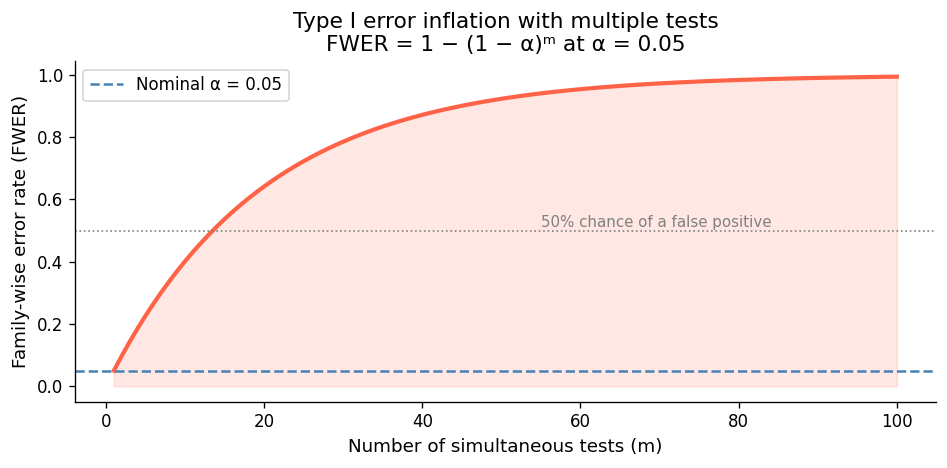

In [12]:
# ── Visualize: FWER inflation ──────────────────────────────────────────────────
m_range = np.arange(1, 101)
fwer = 1 - (1 - 0.05) ** m_range

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(m_range, fwer, color='tomato', lw=2.5)
ax.axhline(0.05, color='steelblue', lw=1.5, ls='--', label='Nominal α = 0.05')
ax.axhline(0.5, color='gray', lw=1, ls=':')
ax.text(55, 0.51, '50% chance of a false positive', fontsize=9, color='gray')
ax.fill_between(m_range, fwer, alpha=0.15, color='tomato')
ax.set_xlabel('Number of simultaneous tests (m)')
ax.set_ylabel('Family-wise error rate (FWER)')
ax.set_title('Type I error inflation with multiple tests\nFWER = 1 − (1 − α)ᵐ at α = 0.05')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Permutation Tests

### 8.1 Why Permutation Tests Exist

Parametric tests (t-test, chi-square) derive p-values from theoretical distributions — the t-distribution, the chi-square distribution. These distributions are valid under specific assumptions: normality (or large $n$ by CLT), independence, etc.

The **permutation test** makes almost none of these assumptions. It builds the null distribution directly from the data by simulating what the test statistic would look like if group labels were assigned at random — i.e., if group membership had no relationship to the outcome.

### 8.2 The Mechanism

Under $H_0$: "group membership is unrelated to outcome," any permutation of the labels is equally likely. So:

1. Compute the observed test statistic $T_{\text{obs}}$.
2. Repeatedly shuffle the group labels, compute $T$ each time → null distribution.
3. p-value = fraction of permuted statistics at least as extreme as $T_{\text{obs}}$:

$$p = \frac{|\{T^{(b)} : |T^{(b)}| \geq |T_{\text{obs}}|\}|}{B}$$

where $B$ is the number of permutations.

### 8.3 When to Prefer Permutation Tests

- Small samples where CLT hasn't kicked in
- Non-normal distributions (skewed, heavy-tailed)
- Custom test statistics with no known parametric distribution
- Any time you want to verify a parametric result without assumption baggage

When parametric assumptions hold, the permutation test converges to the parametric result. When they don't, the permutation test remains valid.

In [13]:
def permutation_test(
    group1: np.ndarray,
    group2: np.ndarray,
    stat_func=None,
    n_permutations: int = 10_000,
    two_tailed: bool = True,
) -> dict:
    """
    Permutation test for difference in means (default) or custom statistic.
    Returns observed statistic, null distribution, and p-value.
    """
    if stat_func is None:
        stat_func = lambda a, b: a.mean() - b.mean()

    observed = stat_func(group1, group2)
    combined = np.concatenate([group1, group2])
    n1 = len(group1)

    null_dist = np.empty(n_permutations)
    for i in range(n_permutations):
        shuffled = rng.permutation(combined)
        null_dist[i] = stat_func(shuffled[:n1], shuffled[n1:])

    if two_tailed:
        p_value = (np.abs(null_dist) >= np.abs(observed)).mean()
    else:
        p_value = (null_dist >= observed).mean()

    return {'observed': observed, 'null_dist': null_dist, 'p_value': p_value}


# ── Compare: Welch t-test vs permutation test for tip% by meal time ────────────
perm_result = permutation_test(lunch, dinner)

print(f"Observed difference in means: {perm_result['observed']:.4f} pp")
print(f"Permutation p-value:  {perm_result['p_value']:.4f}")
print(f"Welch t-test p-value: {result_2samp['p_value']:.4f}")
print(f"\nAgreement: {'YES' if abs(perm_result['p_value'] - result_2samp['p_value']) < 0.05 else 'NO — inspect assumptions'}")

Observed difference in means: 0.4610 pp
Permutation p-value:  0.6101
Welch t-test p-value: 0.5138

Agreement: NO — inspect assumptions


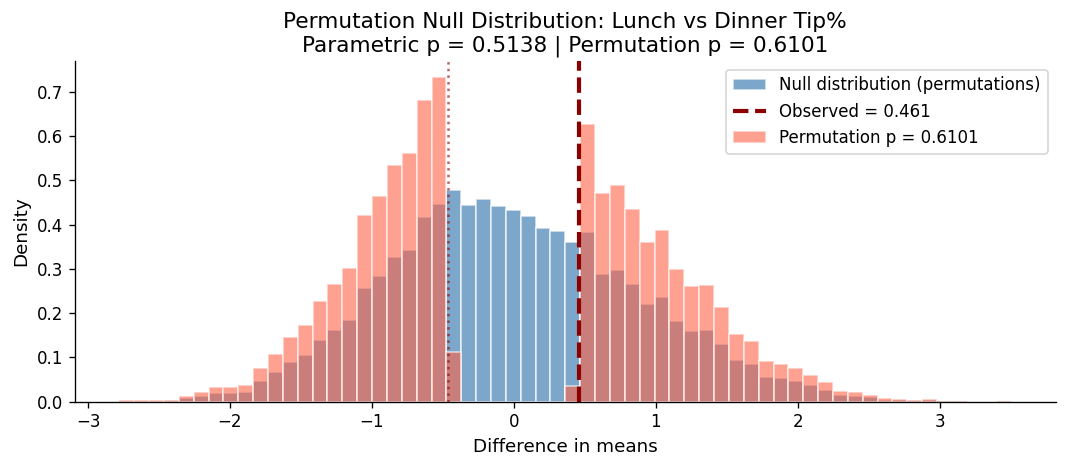

In [14]:
# ── Visualize: null distribution from permutations ────────────────────────────
def plot_permutation_null(
    result: dict, parametric_p: float = None, title: str = 'Permutation Test'
) -> None:
    fig, ax = plt.subplots(figsize=(9, 4))
    null = result['null_dist']
    obs = result['observed']

    ax.hist(null, bins=60, density=True, color='steelblue',
            edgecolor='white', alpha=0.7, label='Null distribution (permutations)')
    ax.axvline(obs, color='darkred', lw=2.5, ls='--', label=f'Observed = {obs:.3f}')
    ax.axvline(-obs, color='darkred', lw=1.5, ls=':', alpha=0.6)

    # Shade p-value area
    extreme = null[np.abs(null) >= np.abs(obs)]
    ax.hist(extreme, bins=60, density=True, color='tomato',
            edgecolor='white', alpha=0.6, label=f'Permutation p = {result["p_value"]:.4f}')

    if parametric_p is not None:
        ax.set_title(f'{title}\nParametric p = {parametric_p:.4f} | Permutation p = {result["p_value"]:.4f}')
    else:
        ax.set_title(title)

    ax.set_xlabel('Difference in means')
    ax.set_ylabel('Density')
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_permutation_null(
    perm_result,
    parametric_p=result_2samp['p_value'],
    title='Permutation Null Distribution: Lunch vs Dinner Tip%'
)

In [15]:
# ── Where permutation and parametric tests diverge: a skewed real example ──────
# House value distribution is right-skewed. Compare high vs low AveRooms.
# Small sample from each group so CLT hasn't fully normalized the mean distribution.

rooms_median = housing['AveRooms'].median()
# Intentionally small samples to stress-test the normality assumption
few_rooms = housing.loc[housing['AveRooms'] <= rooms_median, 'median_house_value_usd'].sample(
    n=25, random_state=42
).values
many_rooms = housing.loc[housing['AveRooms'] > rooms_median, 'median_house_value_usd'].sample(
    n=25, random_state=42
).values

_, p_welch_small = stats.ttest_ind(few_rooms, many_rooms, equal_var=False)
perm_small = permutation_test(few_rooms, many_rooms)

print('Small-sample, skewed data: house value by room count')
print(f'  Welch t-test p     : {p_welch_small:.4f}')
print(f'  Permutation test p : {perm_small["p_value"]:.4f}')
print(f'  Difference         : {abs(p_welch_small - perm_small["p_value"]):.4f}')
print('\nNote: Divergence increases as skew/small-n makes t-distribution approximation worse.')

Small-sample, skewed data: house value by room count
  Welch t-test p     : 0.0182
  Permutation test p : 0.0166
  Difference         : 0.0016

Note: Divergence increases as skew/small-n makes t-distribution approximation worse.


---
## 9. Power Analysis

### 9.1 The Four-Way Relationship

Statistical power is determined by four quantities that are tightly coupled — change one and the others shift:

| Quantity | Symbol | Role |
|---|---|---|
| Significance level | $\alpha$ | Type I error rate you're willing to accept |
| Power | $1 - \beta$ | Probability of detecting a real effect |
| Effect size | $d$ (or $V$, etc.) | Magnitude of the effect |
| Sample size | $n$ | Observations per group |

Fix any three — the fourth is determined. In practice, you fix $\alpha$, $1-\beta$, and your minimum detectable effect size $d$, then solve for the required $n$.

### 9.2 Derivation Intuition for Two-Sample t-Test

Power is the probability that the test statistic exceeds the critical value when the true effect is $\delta = \mu_1 - \mu_2$. The test statistic follows a **non-central t-distribution** with non-centrality parameter:

$$\lambda = \frac{\delta}{\sigma\sqrt{2/n}} = d \cdot \sqrt{n/2}$$

where $d = \delta / \sigma$ is Cohen's $d$ and $n$ is per-group sample size. To achieve power $1-\beta$ at significance $\alpha$ (two-tailed):

$$n \approx \frac{2(z_{\alpha/2} + z_{\beta})^2}{d^2}$$

where $z_{\alpha/2}$ and $z_{\beta}$ are the standard normal quantiles. This is a normal approximation; `scipy.stats` gives the exact calculation using the non-central t-distribution.

In [16]:
def compute_power_two_sample(
    effect_size: float, n_per_group: int, alpha: float = 0.05
) -> float:
    """
    Power of a two-sample Welch t-test.
    Uses non-central t-distribution for exactness.
    effect_size: Cohen's d
    """
    df = 2 * (n_per_group - 1)
    nc = effect_size * np.sqrt(n_per_group / 2)  # non-centrality parameter
    t_crit = stats.t.ppf(1 - alpha / 2, df=df)
    # Power = P(|T| > t_crit | non-central t with nc)
    power = stats.nct.sf(t_crit, df=df, nc=nc) + stats.nct.cdf(-t_crit, df=df, nc=nc)
    return power


def required_n_two_sample(
    effect_size: float, alpha: float = 0.05, power: float = 0.80
) -> int:
    """
    Minimum n per group for a two-sample t-test via normal approximation.
    Returns the smallest n achieving target power.
    """
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)
    n_approx = int(np.ceil(2 * (z_alpha + z_beta) ** 2 / effect_size ** 2))
    # Refine by stepping up until exact power meets target
    n = n_approx
    while compute_power_two_sample(effect_size, n, alpha) < power:
        n += 1
    return n


# ── Applied scenario: detect lunch vs dinner tip% difference ───────────────────
# Use the observed Cohen's d as the minimum detectable effect
d_obs = abs(d_lunch_dinner)

print('Power analysis: Lunch vs Dinner tip% (Welch two-sample t-test)')
print(f"  Observed Cohen's d: {d_obs:.4f}  [{interpret_cohens_d(d_obs)}]")
print()

for target_power in [0.70, 0.80, 0.90]:
    n = required_n_two_sample(d_obs, alpha=0.05, power=target_power)
    actual_power = compute_power_two_sample(d_obs, n, alpha=0.05)
    print(f"  Target power={target_power:.0%}: n={n} per group  "
          f"(actual power={actual_power:.4f})")

print()
print(f"  Current study: n_lunch={len(lunch)}, n_dinner={len(dinner)}")
current_power = compute_power_two_sample(d_obs, min(len(lunch), len(dinner)), alpha=0.05)
print(f"  Power of current study: {current_power:.4f}")

Power analysis: Lunch vs Dinner tip% (Welch two-sample t-test)
  Observed Cohen's d: 0.0754  [negligible]

  Target power=70%: n=2174 per group  (actual power=0.7001)
  Target power=80%: n=2764 per group  (actual power=0.8000)
  Target power=90%: n=3700 per group  (actual power=0.9000)

  Current study: n_lunch=68, n_dinner=176
  Power of current study: 0.0721


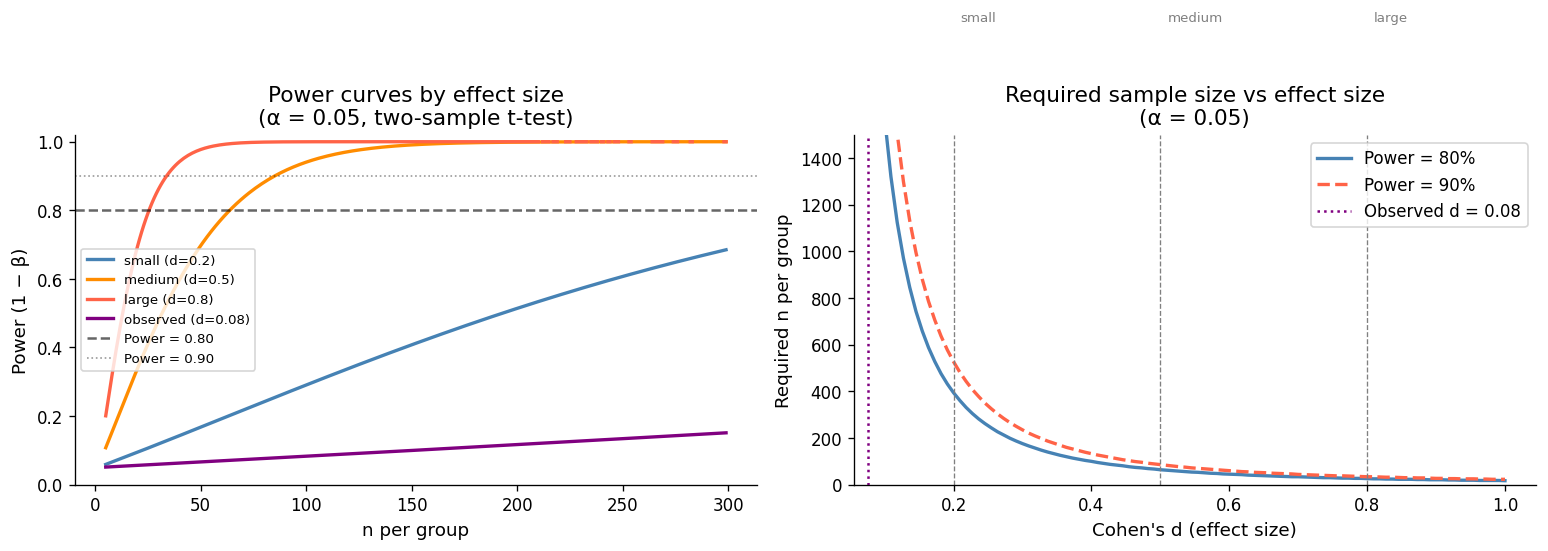

In [17]:
# ── Power curves: the full four-way picture ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Power vs n for different effect sizes
ax = axes[0]
n_range = np.arange(5, 300)
for d_val, label, color in [
    (0.2, 'small (d=0.2)', 'steelblue'),
    (0.5, 'medium (d=0.5)', 'darkorange'),
    (0.8, 'large (d=0.8)', 'tomato'),
    (d_obs, f'observed (d={d_obs:.2f})', 'purple'),
]:
    pwr = [compute_power_two_sample(d_val, n) for n in n_range]
    ax.plot(n_range, pwr, label=label, color=color, lw=2)

ax.axhline(0.80, color='black', lw=1.5, ls='--', alpha=0.6, label='Power = 0.80')
ax.axhline(0.90, color='black', lw=1, ls=':', alpha=0.4, label='Power = 0.90')
ax.set_xlabel('n per group')
ax.set_ylabel('Power (1 − β)')
ax.set_title('Power curves by effect size\n(α = 0.05, two-sample t-test)')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.02)

# Panel 2: Required n vs effect size for target powers
ax = axes[1]
d_range = np.linspace(0.1, 1.0, 100)
for target_power, color, ls in [(0.80, 'steelblue', '-'), (0.90, 'tomato', '--')]:
    n_required = [required_n_two_sample(d, alpha=0.05, power=target_power) for d in d_range]
    ax.plot(d_range, n_required, lw=2, color=color, ls=ls,
            label=f'Power = {target_power:.0%}')

ax.axvline(d_obs, color='purple', lw=1.5, ls=':', label=f'Observed d = {d_obs:.2f}')
for d_mark, label in [(0.2, 'small'), (0.5, 'medium'), (0.8, 'large')]:
    ax.axvline(d_mark, color='gray', lw=0.8, ls='--')
    ax.text(d_mark + 0.01, ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] > 1 else 300,
            label, fontsize=8, color='gray')

ax.set_xlabel("Cohen's d (effect size)")
ax.set_ylabel('Required n per group')
ax.set_title('Required sample size vs effect size\n(α = 0.05)')
ax.legend()
ax.set_ylim(0, 1500)

plt.tight_layout()
plt.show()

---
## Summary: Decision Framework

The table below maps practical scenarios to the right test and the right complementary analysis:

| Scenario | Test | Effect size metric | Watch out for |
|---|---|---|---|
| Sample mean vs known reference | One-sample t-test | Cohen's $d$ vs reference | Is reference value meaningful? |
| Two group means (continuous) | Welch two-sample t-test | Cohen's $d$ | Small n + skew → permutation |
| Two categorical variables | Chi-square ($\geq 5$ expected) | Cramér's $V$ | Small expected counts → Fisher |
| Non-normal, small sample | Permutation test | Raw difference / $d$ | Computation cost for large $n$ |
| Multiple tests simultaneously | Apply Bonferroni or BH | Per-test effect size | Conservative vs power tradeoff |
| Study design / sample sizing | Power analysis | Target $d$, $1-\beta$ | Unrealistic effect size assumptions |

**The most common practitioner errors, in order of frequency:**
1. Reporting p-values without effect sizes
2. Interpreting $p > 0.05$ as "no effect" rather than "insufficient evidence"
3. Running many tests without any correction and highlighting the one that crossed 0.05
4. Designing studies without a power calculation and then concluding from underpowered null results
5. Choosing one-tailed tests after seeing which direction the data fell